In [1]:
from create_percent_diff_summary import invert_dotson_fcn, invert_pig_fcn, invert_thwaites_fcn, invert_amundsen_fcn,eval_models, collect_r2_scores, plot_r2_heatmap_with_symbols, replace_features_with_symbols
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colorbar as colorbar
import os
import sys
import copy
import pickle
import pandas as pd
import firedrake
from scipy.spatial import cKDTree

2025-08-20 03:42:28.341561: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 03:42:28.345809: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 03:42:28.358694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755661348.382281   13362 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755661348.390412   13362 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-20 03:42:28.419287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
inv_amundsen = invert_amundsen_fcn()
df = inv_amundsen.get_dataframe(inv_amundsen.inverse_u)

Reading local outline
Creating mesh
Reading mesh
Reading bedmachine data
Initializing function spaces
Initializing 3d function spaces
Initializing fields
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
C0 is constant: 0.01
Defining friction law
Defining friction law
using englacial temperature for rate factor
Geophysics data imported
Using loss function without sigma

Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.489273e+08   4.828976e+03                  2.885634e+04   
  1     5.951057e+07   2.114047e+03   2.885634e+04   7.214086e+04   3         2         0         2         2         
  2     5.951057e+07   2.114047e+03   7.214086e+04   4.508804e+03   4         2         2         2         2         
  3     5.104125e+07   1.663927e+03   4.508804e+03   1.127201e+04   5         3         0         1  

In [3]:
inv_loss_amundsen = firedrake.assemble(inv_amundsen.loss_functional_nosigma(inv_amundsen.inverse_u))
print(f"Cost function for Amundsen: {inv_loss_amundsen}")

Cost function for Amundsen: 2189.225302959573


In [4]:
def get_phi(h, s):
    g = 9769603575225600.0
    ρ_I = 9.207917118369125e-19
    ρ_W = 1.0282341471330407e-18

    p_W = ρ_W * g * np.maximum(0, h - s)
    p_I = ρ_I * g * h

    # Avoid division by zero with a safe divide
    phi = np.where(p_I > 0, np.maximum((1 - p_W / p_I), 0), 0)
    return phi

def process_csv(filename):
    df = pd.read_csv(filename, index_col=0)
    df = df.sample(frac=1).reset_index(drop=True)
    df['vel_mag'] = np.sqrt(df['x_velocity']**2 + df['y_velocity']**2)
    df['driving_stress'] = df['h'] * 9.8 * df['mag_s']
    df['phi'] = get_phi(df['h'].to_numpy(), df['s'].to_numpy())
    return df

In [5]:
df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')
df_amundsen = process_csv('regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12.csv')
# line coordinates
x_line = -1.625e6
y_min, y_max = -2e5, 30000

# condition for being in df_left
mask_left = (df_pig['x'] < x_line) & (df_pig['y'] >= y_min) & (df_pig['y'] <= y_max)

# split
df_pig_left = df_pig[mask_left].copy()
df_pig_right = df_pig[~mask_left].copy()

In [6]:
# Prepare training data
coords_pig = df_pig[['x', 'y']].values
coords_thwaites = df_thwaites[['x', 'y']].values
coords_dotson = df_dotson[['x', 'y']].values
coords_pig_left = df_pig_left[['x', 'y']].values
coords_pig_right = df_pig_right[['x', 'y']].values

# Build KD-Trees for fast distance queries
tree_pig = cKDTree(coords_pig)
tree_thwaites = cKDTree(coords_thwaites)
tree_dotson = cKDTree(coords_dotson)
tree_pig_left = cKDTree(coords_pig_left)
tree_pig_right = cKDTree(coords_pig_right)

# Prepare test data
coords_test = df_amundsen[['x', 'y']].values

In [11]:
from firedrake import dx, max_value, conditional, interpolate, split, sqrt, Function
import numpy as np

def return_percent_diff(inv_obj, select_dataset, tree_pig_left, tree_pig_right,
                        threshold=0.1, distance_threshold=2000):
    # Compute norms of velocity fields
    u_inv_norm = inv_obj.get_magnitude(inv_obj.inverse_u)
    u_default_norm = inv_obj.get_magnitude(inv_obj.default_u)
    u_ML_norm = inv_obj.get_magnitude(inv_obj.ML_u)
    phi = inv_obj.compute_phi()

    # Extract mesh coordinates
    x, y = split(interpolate(inv_obj.V.mesh().coordinates, inv_obj.V))
    x_npy = interpolate(x, inv_obj.Q).dat.data_ro[:]
    y_npy = interpolate(y, inv_obj.Q).dat.data_ro[:]
    coords = np.vstack((x_npy, y_npy)).T

    # Query distances to each glacier training dataset
    d_pig_left, _ = tree_pig_left.query(coords, k=1)
    d_pig_right, _ = tree_pig_right.query(coords, k=1)

    # Determine closest glacier
    dists = np.vstack([d_pig_left, d_pig_right]).T
    closest_glacier = np.argmin(dists, axis=1)
    min_dist = np.min(dists, axis=1)

    # Assign labels: 0=pig_left, 1=pig_right, 2=Other
    labels = np.where(min_dist > distance_threshold, 2, closest_glacier)

    # Define which glaciers were used for training
    training_glaciers = {
        6: [6],  # pig_left
        7: [7],  # pig_right
    }
    training_ids = set(training_glaciers[select_dataset])

    # Create a binary mask: 1 for test region, 0 for training region
    non_training_mask_npy = np.array([1 if label not in training_ids else 0 for label in labels])
    non_training_mask = Function(inv_obj.Q)
    non_training_mask.dat.data[:] = non_training_mask_npy

    # Define region of interest: where phi > threshold and not in training area
    phi_condition = conditional(phi > threshold, 1, 0)
    combined_mask = phi_condition * non_training_mask

    # Calculate percent difference between default and ML solutions
    ml_difference = sqrt((u_inv_norm - u_ML_norm) ** 2)
    default_difference = sqrt((u_inv_norm - u_default_norm) ** 2)
    percent_difference = 100 * (default_difference - ml_difference) / default_difference
    percent_difference_capped = max_value(percent_difference, 0)
    percent_100 = 100 * default_difference / default_difference  # = 100

    # Assemble metric over valid regions
    numerator = firedrake.assemble(percent_difference_capped * combined_mask * dx)
    denominator = firedrake.assemble(percent_100 * combined_mask * dx)

    return numerator / denominator if denominator != 0 else 0

In [12]:
def compute_area_fraction_above_threshold(
    inv_obj, select_dataset, tree_pig_left, tree_pig_right,
    percent_diff_threshold=70.0, threshold=0.1, distance_threshold=2000
):
    # Compute velocity magnitudes
    u_inv_norm = inv_obj.get_magnitude(inv_obj.inverse_u)
    u_default_norm = inv_obj.get_magnitude(inv_obj.default_u)
    u_ML_norm = inv_obj.get_magnitude(inv_obj.ML_u)
    phi = inv_obj.compute_phi()

    # Coordinates
    x, y = split(interpolate(inv_obj.V.mesh().coordinates, inv_obj.V))
    x_npy = interpolate(x, inv_obj.Q).dat.data_ro[:]
    y_npy = interpolate(y, inv_obj.Q).dat.data_ro[:]
    coords = np.vstack((x_npy, y_npy)).T

    # Query distances to pig_left and pig_right
    d_pig_left, _ = tree_pig_left.query(coords, k=1)
    d_pig_right, _ = tree_pig_right.query(coords, k=1)

    # Determine closest glacier
    dists = np.vstack([d_pig_left, d_pig_right]).T
    closest_glacier = np.argmin(dists, axis=1)
    min_dist = np.min(dists, axis=1)

    # Assign labels: 0=pig_left, 1=pig_right, 2=Other
    labels = np.where(min_dist > distance_threshold, 2, closest_glacier)

    # Define which glaciers were used for training
    training_glaciers = {
        6: [6],  # pig_left
        7: [7],  # pig_right
    }
    training_ids = set(training_glaciers[select_dataset])

    # Create a binary mask: 1 for test region, 0 for training region
    non_training_mask_npy = np.array([1 if label not in training_ids else 0 for label in labels])
    non_training_mask = Function(inv_obj.Q)
    non_training_mask.dat.data[:] = non_training_mask_npy
    phi_condition = conditional(phi > threshold, 1, 0)
    combined_mask = phi_condition * non_training_mask

    # % improvement
    ml_difference = sqrt((u_inv_norm - u_ML_norm) ** 2)
    default_difference = sqrt((u_inv_norm - u_default_norm) ** 2)
    percent_difference = 100 * (default_difference - ml_difference) / default_difference
    percent_difference_capped = max_value(percent_difference, 0)

    # Evaluate coverage
    high_improvement_mask = conditional(percent_difference_capped >= percent_diff_threshold, 1, 0)
    improved_area = firedrake.assemble(high_improvement_mask * combined_mask * dx)
    total_test_area = firedrake.assemble(combined_mask * dx)

    if total_test_area == 0:
        return 0.0  # avoid divide-by-zero

    return improved_area / total_test_area

In [14]:
from create_percent_diff_summary import compute_u_avg, get_phi, process_csv, regression
def compute_C_mean(select_dataset = 0, phi_threshold=0.1):
    # df_pig = process_csv('regularized_const_01C_simultaneous_pig_r1_geo_12.csv')
    # df_thwaites = process_csv('regularized_const_01C_simultaneous_thwaites_r1_geo_12.csv')
    # df_dotson = process_csv('regularized_const_01C_simultaneous_dotson_r1_geo_12.csv')

    # df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r01_geo_12.csv')
    # df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r01_geo_12.csv')
    # df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r01_geo_12.csv')

    df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
    df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
    df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')
    # line coordinates
    x_line = -1.625e6
    y_min, y_max = -2e5, 30000

    # condition for being in df_left
    mask_left = (df_pig['x'] < x_line) & (df_pig['y'] >= y_min) & (df_pig['y'] <= y_max)

    # split
    df_pig_left = df_pig[mask_left].copy()
    df_pig_right = df_pig[~mask_left].copy()

    if select_dataset == 0:
        df = pd.concat([df_dotson,df_dotson,df_thwaites], ignore_index=True)
        print("dataset selected: [df_dotson,df_dotson,df_thwaites]") 
    elif select_dataset == 1:
        df = pd.concat([df_pig,df_pig,df_thwaites], ignore_index=True)
        print("dataset selected: [df_pig,df_pig,df_thwaites]") 
    elif select_dataset == 2:
        df = pd.concat([df_dotson,df_pig], ignore_index=True)
        print("dataset selected: [df_dotson,df_pig]") 
    elif select_dataset == 3:
        df = pd.concat([df_dotson], ignore_index=True)
        print("dataset selected: [df_dotson]") 
    elif select_dataset == 4:
        df = pd.concat([df_pig], ignore_index=True)
        print("dataset selected: [df_pig]") 
    elif select_dataset == 5:
        df = pd.concat([df_thwaites], ignore_index=True)
        print("dataset selected: [df_thwaites]")
    elif select_dataset == 6:
        df = df_pig_left.copy()
        print("dataset selected: [df_pig_left]")
    elif select_dataset == 7:
        df = df_pig_right.copy()
        print("dataset selected: [df_pig_right]")
    else:
        raise ValueError("Invalid select_dataset value. Must be between 0 and 7.")
    
    # Compute phi
    df['phi'] = df.apply(lambda row: get_phi(row['h'], row['s']), axis=1)
    #C_mean = df['C'].mean()
    C_mean = df.loc[df['phi'] > phi_threshold, 'C'].mean()
    return C_mean

def eval_models(select_dataset, invert_obj):
    C_mean = compute_C_mean(select_dataset)
    compute_u_avg(invert_obj, C_mean)
    if select_dataset == 0:
        base_folder = 'mlp_ensemble_englacial_0' 
    elif select_dataset == 1:
        base_folder = 'mlp_ensemble_englacial_1'
    elif select_dataset == 2:
        base_folder = 'mlp_ensemble_englacial_2' 
    elif select_dataset == 3:
        base_folder = 'mlp_ensemble_englacial_3'
    elif select_dataset == 4:
        base_folder = 'mlp_ensemble_englacial_4'
    elif select_dataset == 5:
        base_folder = 'mlp_ensemble_englacial_5'
    elif select_dataset == 6:
        base_folder = 'mlp_ensemble_englacial_6'
    elif select_dataset == 7:
        base_folder = 'mlp_ensemble_englacial_7'
    else:
        raise ValueError("Invalid select_dataset value. Must be between 0 and 7.")
    summary_list = []
    class_list = []
    u_optimized_list = []
    loss_function_list = []

    error_list = []
    columns_list = []
    df_summary_list = []

    # Collect all temp objects for later plotting
    temp_objects = []

    for folder in os.listdir(base_folder):
        if not os.path.isdir(os.path.join(base_folder, folder)):
            continue  # Skip if not a directory
        
        try:
            # Skip folders that don't contain numeric names (if needed)
            folder_num = int(folder)
        except ValueError:
            continue
        
        print('Processing folder:', folder)
        path = os.path.join(base_folder, folder)
        files = [f for f in os.listdir(path) if f.endswith('.pkl')]
        
        if not files:
            print(f"No .pkl files found in folder {folder}. Skipping.")
            continue
        
        temp_object = copy.copy(invert_obj)
        columns = None
        r2_list, r2_adjusted_list, mse_list = [], [], []
        
        for file in files:
            try:
                with open(os.path.join(path, file), "rb") as f:
                    model_bundle = pickle.load(f)
                    r2_list.append(model_bundle['r2_test'])
                    r2_adjusted_list.append(model_bundle['r2_adjusted_test'])
                    mse_list.append(model_bundle['mse_test'])
                    columns = model_bundle.get('input_columns', columns)
            except Exception as e:
                print(f"Error processing file {file} in folder {folder}: {e}")
                continue
        if r2_list and r2_adjusted_list and mse_list:
            r2_stats = pd.DataFrame(r2_list).describe()
            r2_adjusted_stats = pd.DataFrame(r2_adjusted_list).describe()
            mse_stats = pd.DataFrame(mse_list).describe()
            
            summary_list.append({
                'input_columns': columns,
                'r2_mean': r2_stats.loc['mean'].values[0],
                'r2_std': r2_stats.loc['std'].values[0],
                'r2_median': r2_stats.loc['50%'].values[0],
                'r2_adjusted_mean': r2_adjusted_stats.loc['mean'].values[0],
                'r2_adjusted_std': r2_adjusted_stats.loc['std'].values[0],
                'r2_adjusted_median': r2_adjusted_stats.loc['50%'].values[0],
                'mse_mean': mse_stats.loc['mean'].values[0],
                'mse_std': mse_stats.loc['std'].values[0],
                'mse_median': mse_stats.loc['50%'].values[0]
            })
        

        model_name = files[0][:-8]  # Assumes model files end with a fixed pattern (e.g., '_model.pkl')
        print(model_name)
        print(columns)
        columns_list.append(columns)
        
        # Ensure the model_name is properly constructed
        model_file_path = os.path.join(base_folder, folder, model_name)
        temp_object.C = firedrake.Function(temp_object.Q)
        temp_object = regression(temp_object, model_file_path, C_bounds = [-50, 55])
        
        try:
            u_optimized = temp_object.simulation()
        except:
            print('Error in simulation')
            try:
                temp_object.opts = {"dirichlet_ids": temp_object.drichlet_ids,
                                "side_wall_ids": temp_object.side_ids,
                            "diagnostic_solver_type": "icepack",
                            "diagnostic_solver_parameters": {
                                "max_iterations":50,},}
                temp_object.create_model_weertman()
                u_optimized = temp_object.simulation()
            except:
                print('Error in simulation again reducing C bounds')
                try:
                    temp_object = regression(temp_object, model_file_path, C_bounds = [-24, 45])
                    u_optimized = temp_object.simulation()
                except:
                    print('Error in simulation again reducing C bounds 2nd time')
                    try:
                        temp_object = regression(temp_object, model_file_path, C_bounds = [-11, 2])
                        u_optimized = temp_object.simulation()
                    except:
                        print('Error in simulation assigning u_optimized')
                        temp_object.C = firedrake.Function(temp_object.Q)
                        u_optimized =  temp_object.simulation()

        temp_object.opts = {"dirichlet_ids": temp_object.drichlet_ids,
                    "side_wall_ids": temp_object.side_ids,
                   "diagnostic_solver_type": "petsc",
                "diagnostic_solver_parameters": {
                    "snes_type": "newtontr",
                    "ksp_type": "gmres",
                    "pc_type": "lu",
                    "pc_factor_mat_solver_type": "mumps",},}

            

        # Store or process `u_optimized` as needed
        u_optimized_list.append(u_optimized)
        loss_val = firedrake.assemble(temp_object.loss_functional_nosigma(u_optimized))
        loss_function_list.append(loss_val)
        temp_object.ML_u = u_optimized
        # Collect the temp object for plotting later
        temp_objects.append(temp_object)
    return temp_objects, summary_list, columns_list, u_optimized_list, loss_function_list


In [ ]:
import seaborn as sns
from create_percent_diff_summary import FEATURE_SYMBOLS, DATASET_NAMES, TRAINING_MAPPING, CATCHMENT_NAMES

# Initialize a storage dictionary
eval_results = {}

# Precompute and store results for all datasets
for select_dataset in range(6, 8):  # 6 for pig_left, 7 for pig_right
    # Collect R2 scores
    print(f"Processing dataset {select_dataset}...")
    
    eval_results[select_dataset] = {
        "amundsen": eval_models(select_dataset, inv_amundsen)
              }

In [16]:
from create_percent_diff_summary import mapping_features

In [17]:
def reorder_list(lst, index_order):
    # Pair each element in lst with its corresponding index from index_order
    paired = list(zip(index_order, lst))
    
    # Sort the pairs based on the indices from index_order
    paired.sort()
    
    # Extract the sorted elements (second item of the pair) to get the reordered list
    sorted_list = [item[1] for item in paired]
    
    return sorted_list

In [19]:
all_percent_explained_avg = []

for select_dataset in range(6, 8):  # 6 for pig_left, 7 for pig_right
    print(f"Analyzing dataset {select_dataset}...")

    # Retrieve precomputed results for "amundsen"
    temp_objects_amundsen, summary_list_amundsen, columns_list_amundsen, u_optimized_list_amundsen, loss_function_list_amundsen = eval_results[select_dataset]["amundsen"]

    # Reorder using mapping_features if necessary
    index_order = []
    for i in range(len(columns_list_amundsen)):
        for key, value in mapping_features.items():
            if set(value) == set(columns_list_amundsen[i]):
                index_order.append(key)
                break

    temp_objects_amundsen = reorder_list(temp_objects_amundsen, index_order)
    summary_list_amundsen = reorder_list(summary_list_amundsen, index_order)
    u_optimized_list_amundsen = reorder_list(u_optimized_list_amundsen, index_order)
    loss_function_list_amundsen = reorder_list(loss_function_list_amundsen, index_order)
    columns_list_amundsen = reorder_list(columns_list_amundsen, index_order)

    print(columns_list_amundsen)

    # Calculate percent explained for each feature subset
    percent_explained = [return_percent_diff(obj, select_dataset, tree_pig_left, tree_pig_right,
                       threshold=0.1, distance_threshold=2000) for obj in temp_objects_amundsen]
    #percent_explained_avg = np.mean(percent_explained, axis=0)  # Not really needed if already 1D
    all_percent_explained_avg.append(percent_explained)
all_percent_explained_avg = np.array(all_percent_explained_avg)

Analyzing dataset 6...
[['s', 'h', 'mag_h', 'mag_s', 'surface_air_temp'], ['b', 'mag_b', 'heatflux', 'mag_anomaly']]
Analyzing dataset 7...
[['s', 'h', 'mag_h', 'mag_s', 'surface_air_temp'], ['b', 'mag_b', 'heatflux', 'mag_anomaly']]


In [43]:
all_percent_explained_avg 

array([[0.04569497, 0.07430428],
       [0.47622388, 0.51870877]])

In [21]:
all_area_fractions_above_threshold = []

for select_dataset in range(6, 8):  # 6 for pig_left, 7 for pig_right
    print(f"Analyzing dataset {select_dataset}...")

    # Retrieve precomputed results for "amundsen"
    temp_objects_amundsen, summary_list_amundsen, columns_list_amundsen, u_optimized_list_amundsen, loss_function_list_amundsen = eval_results[select_dataset]["amundsen"]

    # Reorder if needed
    index_order = []
    for i in range(len(columns_list_amundsen)):
        for key, value in mapping_features.items():
            if set(value) == set(columns_list_amundsen[i]):
                index_order.append(key)
                break

    temp_objects_amundsen = reorder_list(temp_objects_amundsen, index_order)
    summary_list_amundsen = reorder_list(summary_list_amundsen, index_order)
    u_optimized_list_amundsen = reorder_list(u_optimized_list_amundsen, index_order)
    loss_function_list_amundsen = reorder_list(loss_function_list_amundsen, index_order)
    columns_list_amundsen = reorder_list(columns_list_amundsen, index_order)

    print(columns_list_amundsen)

    # Compute fraction of test area with ≥ 70% improvement
    area_fraction_above_threshold = [
        compute_area_fraction_above_threshold(
            obj, select_dataset, tree_pig_left, tree_pig_right,
            percent_diff_threshold=70.0,
            threshold=0.1,
            distance_threshold=2000
        )
        for obj in temp_objects_amundsen
    ]

    all_area_fractions_above_threshold.append(area_fraction_above_threshold)

all_area_fractions_above_threshold = np.array(all_area_fractions_above_threshold)


Analyzing dataset 6...
[['s', 'h', 'mag_h', 'mag_s', 'surface_air_temp'], ['b', 'mag_b', 'heatflux', 'mag_anomaly']]
Analyzing dataset 7...
[['s', 'h', 'mag_h', 'mag_s', 'surface_air_temp'], ['b', 'mag_b', 'heatflux', 'mag_anomaly']]


In [22]:
from create_percent_diff_summary import change_feature_label

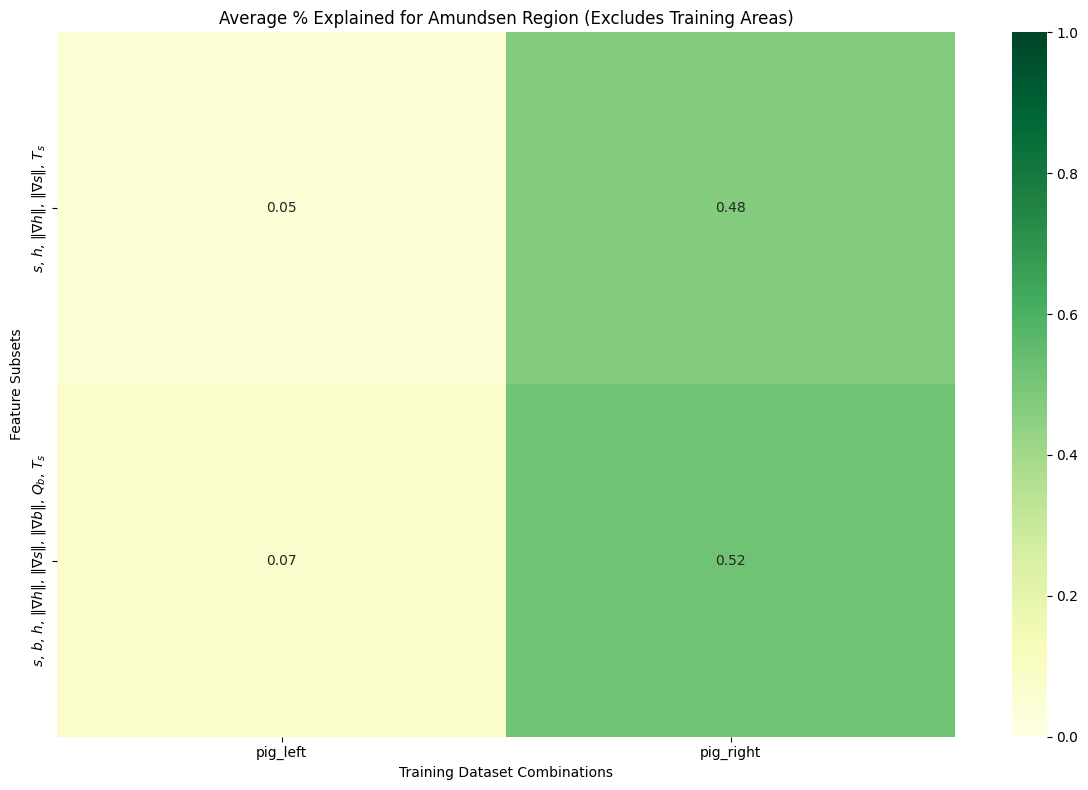

In [45]:
# Combine results into a DataFrame for heatmap
# Use the reordered columns_list_amundsen from the last loop
FEATURE_SYMBOLS = {
    "s": r"$s$",
    "b": r"$b$",
    "h": r"$h$",
    "mag_s": r"$\|\nabla s\|$",
    "mag_b": r"$\|\nabla b\|$",
    "mag_h": r"$\|\nabla h\|$",
    "driving_stress": r"$\tau_d$",
    "gravity_disturbance": r"$g_d$",
    "heatflux": r"$Q_b$",
    "surface_air_temp": r"$T_s$",
    "snow_accumulation": r"$A_s$",
    "mag_anomaly": r"$g_b$",
}

def change_feature_label(feature_labels):
    new_order = [r"$s$", r"$b$", r"$h$", r"$\|\nabla h\|$", r"$\|\nabla s\|$", r"$\|\nabla b\|$",    r"$Q_b$",    r"$T_s$"]
    for idx, features in enumerate(feature_labels):
        if set(features) == set(new_order):
            break
    #print(idx)
    feature_labels[idx] = new_order
feature_labels = [[FEATURE_SYMBOLS.get(col, col) for col in sublist] for sublist in columns_list_amundsen]
change_feature_label(feature_labels)
feature_labels_strings = [', '.join(sublist) for sublist in feature_labels]

# Define the ice and geophysical feature types
ice_features = {"s", "h", "mag_s", "mag_h"}
geophysical_features = {"b", "mag_b", "driving_stress", "gravity_disturbance", "heatflux", "surface_air_temp"}

# Function to apply color based on feature type
def get_feature_color(feature):
    if feature in ice_features:
        return "blue"
    elif feature in geophysical_features:
        return "brown"
    else:
        return "black"  # Default color if not classified

# Apply color coding for each feature
colored_labels = [
    [get_feature_color(col) for col in sublist] 
    for sublist in feature_labels
]

DATASET_NAMES = [
    "pig_left",
    "pig_right"]
# Create DataFrame for heatmap: rows = features, columns = dataset numbers (0–5)
heatmap_data = pd.DataFrame(
    np.array(all_percent_explained_avg).T,  # Transpose to make features rows
    index=feature_labels_strings,
    columns=DATASET_NAMES
)

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGn",  # Yellow-Green colormap
    cbar=True,
    vmin=0,
    vmax=1
)
plt.title("Average % Explained for Amundsen Region (Excludes Training Areas)")
plt.xlabel("Training Dataset Combinations")
plt.ylabel("Feature Subsets")
plt.tight_layout()
plt.show()


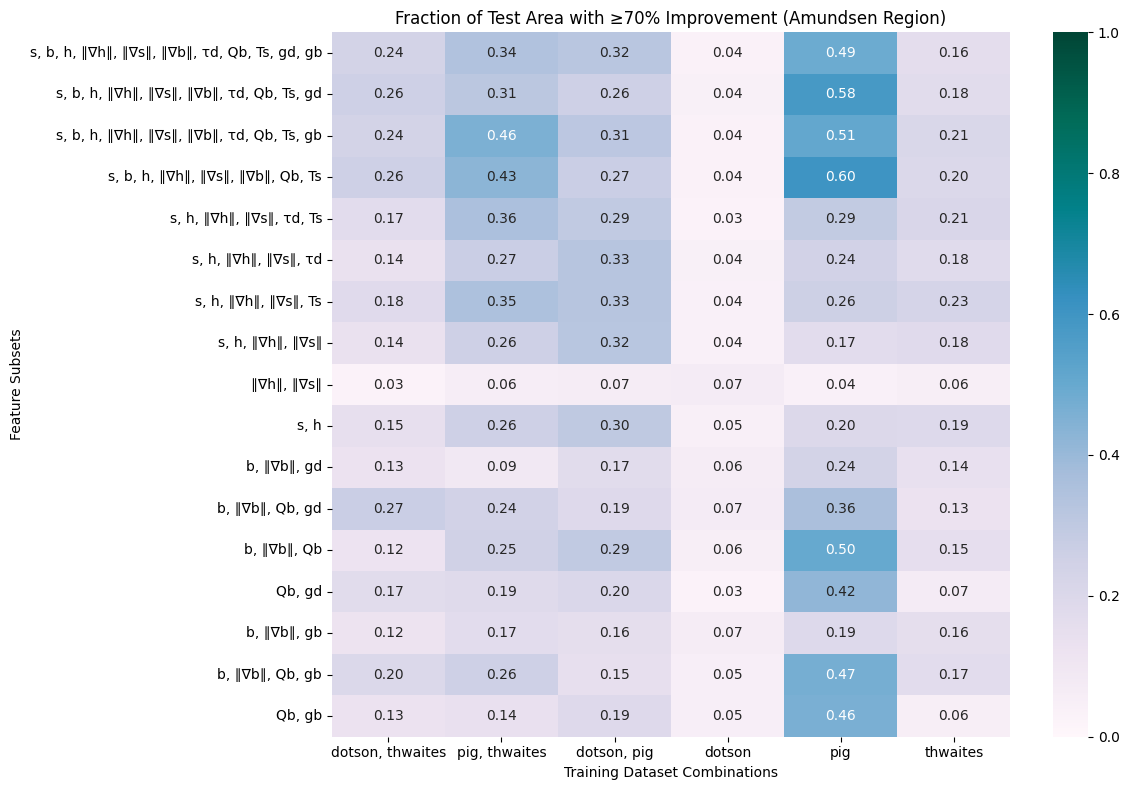

In [24]:
# Convert feature names to labels again (reuse last columns_list_amundsen from loop)
feature_labels = [[FEATURE_SYMBOLS.get(col, col) for col in sublist] for sublist in columns_list_amundsen]
change_feature_label(feature_labels)
feature_labels_strings = [', '.join(sublist) for sublist in feature_labels]

# Create DataFrame for heatmap: rows = feature subsets, columns = dataset indices
heatmap_data_area_fraction = pd.DataFrame(
    np.array(all_area_fractions_above_threshold).T,  # Transpose for feature-major layout
    index=feature_labels_strings,
    columns=DATASET_NAMES
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data_area_fraction,
    annot=True,
    fmt=".2f",
    cmap="PuBuGn",  # Green-blue gradient
    cbar=True,
    vmin=0,
    vmax=1
)
plt.title("Fraction of Test Area with ≥70% Improvement (Amundsen Region)")
plt.xlabel("Training Dataset Combinations")
plt.ylabel("Feature Subsets")
plt.tight_layout()
plt.show()


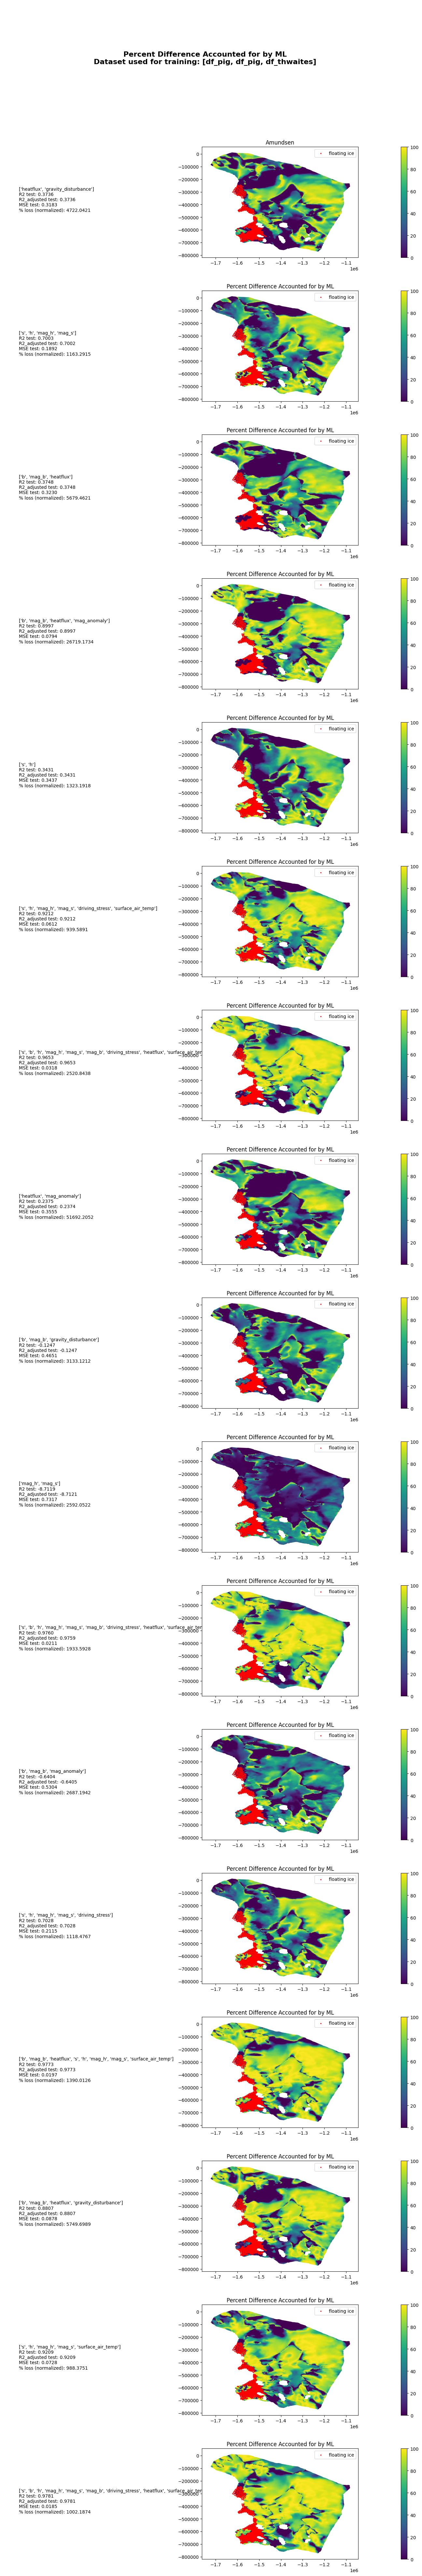

In [96]:
select_dataset = 1
# Determine the dataset used based on select_dataset
if select_dataset == 0:
    dataset_used = "[df_dotson, df_dotson, df_thwaites]"
elif select_dataset == 1:
    dataset_used = "[df_pig, df_pig, df_thwaites]"
elif select_dataset == 2:
    dataset_used = "[df_dotson, df_pig]"
elif select_dataset == 3:
    dataset_used = "[df_dotson]"
elif select_dataset == 4:
    dataset_used = "[df_pig]"
elif select_dataset == 5:
    dataset_used = "[df_thwaites]"

# Load data for Amundsen only
temp_objects_amundsen, summary_list_amundsen, columns_list_amundsen, u_optimized_list_amundsen, loss_function_list_amundsen = eval_results[select_dataset]["amundsen"]

n_rows = len(temp_objects_amundsen)
fig = plt.figure(figsize=(16, 6 * n_rows))
gs = gridspec.GridSpec(n_rows + 1, 3, width_ratios=[5, 5, 0.2], wspace=0.4, hspace=0.3)

# Title
ax_title = fig.add_subplot(gs[0, :])
title_text = f"Percent Difference Accounted for by ML\nDataset used for training: {dataset_used}"
ax_title.text(0.5, 0.5, title_text, fontsize=16, weight='bold', ha='center', va='center')
ax_title.axis('off')

# Plot each feature subset
for row in range(n_rows):
    # Description
    ax_summary = fig.add_subplot(gs[row + 1, 0])
    summary_text = (
        f"{columns_list_amundsen[row]}\n"
        f"R2 test: {summary_list_amundsen[row]['r2_mean']:.4f}\n"
        f"R2_adjusted test: {summary_list_amundsen[row]['r2_adjusted_mean']:.4f}\n"
        f"MSE test: {summary_list_amundsen[row]['mse_mean']:.4f}\n"
        f"% loss (normalized): {(loss_function_list_amundsen[row] - inv_loss_amundsen) / inv_loss_amundsen:.4f}\n"
        #f"% explained: {return_percent_diff(temp_objects_amundsen[row]):.4f}"
    )
    ax_summary.text(0.1, 0.5, summary_text, fontsize=10, va="center", ha="left")
    ax_summary.axis('off')

    # Plot
    ax_plot = fig.add_subplot(gs[row + 1, 1])
    _, ax_plot = temp_objects_amundsen[row].plot_percent_accounted(vmin=0, vmax=100, axes=ax_plot)
    if row == 0:
        ax_plot.set_title("Amundsen")

    # Colorbar
    cax = fig.add_subplot(gs[row + 1, 2])
    fig.colorbar(ax_plot.collections[0], cax=cax)

plt.show()

In [24]:
def plot_percent_accounted(inv_obj, vmin=None, vmax=None, axes=None, threshold=0.1, buffer=0.01):
    import firedrake

    percent_difference = inv_obj.calculate_percent_accounted()
    percent_difference_fcn = firedrake.interpolate(percent_difference, inv_obj.Q)

    # Plot on provided axes or create new if None
    if axes is None:
        fig, axes = inv_obj.plot_bounded_antarctica()
    else:
        fig = None

    colors = firedrake.tripcolor(percent_difference_fcn, axes=axes, vmax=vmax, vmin=vmin)

    # Add colorbar only if no external axes were provided
    #if fig is not None:
        #fig.colorbar(colors)

    ϕ = inv_obj.get_phi(inv_obj.h, inv_obj.s)
    Q_temp = firedrake.FunctionSpace(inv_obj.mesh, family="CG", degree=1)
    line = firedrake.interpolate(ϕ, Q_temp)

    # Extract coordinates where phi meets the threshold
    phi_values = line.dat.data[:]
    x = line.function_space().mesh().coordinates.dat.data[:, 0]
    y = line.function_space().mesh().coordinates.dat.data[:, 1]

    # Select coordinates where phi is less than or equal to threshold + buffer
    x_coords = x[(phi_values <= threshold + buffer)]
    y_coords = y[(phi_values <= threshold + buffer)]

    #axes.set_xlabel("UPS x [m]", fontsize=18)  # Adjust font size for x-axis label
    axes.set_ylabel("UPS y [m]", fontsize=18)  # Adjust font size for y-axis label
    axes.tick_params(axis='x', labelsize=18)  # Adjust font size for x-axis ticks
    axes.tick_params(axis='y', labelsize=18)  # Adjust font size for y-axis ticks
    #axes.set_xticklabels([])
    #axes.tick_params(axis='y', labelleft=False)

    # Overlay red dots on the plot
    if len(x_coords) > 0:
        axes.scatter(x_coords, y_coords, color='white', s=5, label='floating ice')
        #axes.legend()

        # Add horizontal colorbar above the image only if figure exists
    if fig is not None:
        # Get axis position to align colorbar width with the plot
        bbox = axes.get_position()
        cbar_height = 0.02  # Thickness of the colorbar
        cbar_pad = 0.01     # Gap between plot and colorbar

        # Create a new axis above the current plot for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0,
            bbox.y1 + cbar_pad,
            bbox.width,
            cbar_height
        ])

        cbar = fig.colorbar(
            colors,
            cax=cbar_ax,
            orientation='horizontal'
        )
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        cbar.set_label("% explained", fontsize=18)
        cbar.ax.tick_params(labelsize=18)

    #axes.set_title('Percent Difference Accounted for by ML')
    return fig, axes


In [25]:
def plot_C(inv_obj, vmin=-2, vmax=5, axes=None, threshold=0.1, buffer=0.01):
    import firedrake

    #percent_difference = inv_obj.calculate_percent_accounted()
    #percent_difference_fcn = firedrake.interpolate(percent_difference, inv_obj.Q)

    # Plot on provided axes or create new if None
    if axes is None:
        fig, axes = inv_obj.plot_bounded_antarctica()
    else:
        fig = None

    colors = firedrake.tripcolor(inv_obj.C, axes=axes, vmax=vmax, vmin=vmin)

    # Add colorbar only if no external axes were provided
    #if fig is not None:
    #    fig.colorbar(colors)

    ϕ = inv_obj.get_phi(inv_obj.h, inv_obj.s)
    Q_temp = firedrake.FunctionSpace(inv_obj.mesh, family="CG", degree=1)
    line = firedrake.interpolate(ϕ, Q_temp)

    # Extract coordinates where phi meets the threshold
    phi_values = line.dat.data[:]
    x = line.function_space().mesh().coordinates.dat.data[:, 0]
    y = line.function_space().mesh().coordinates.dat.data[:, 1]

    # Select coordinates where phi is less than or equal to threshold + buffer
    x_coords = x[(phi_values <= threshold + buffer)]
    y_coords = y[(phi_values <= threshold + buffer)]

    #axes.set_xlabel("UPS x [m]", fontsize=18)  # Adjust font size for x-axis label
    #axes.set_ylabel("UPS y [m]", fontsize=18)  # Adjust font size for y-axis label
    axes.tick_params(axis='x', labelsize=18)  # Adjust font size for x-axis ticks
    #axes.tick_params(axis='y', labelsize=18)  # Adjust font size for y-axis ticks
    axes.tick_params(axis='y', labelleft=False)
    #axes.set_xticklabels([])
    axes.set_yticklabels([])

    # Overlay red dots on the plot
    if len(x_coords) > 0:
        axes.scatter(x_coords, y_coords, color='white', s=5, label='floating ice')
        #axes.legend()

    # # Add horizontal colorbar above the image only if figure exists
    if fig is not None:
        # Match colorbar width to the axis
        bbox = axes.get_position()
        cbar_height = 0.02  # Controls colorbar thickness
        cbar_pad = 0.01     # Distance above plot

        cbar_ax = fig.add_axes([
            bbox.x0,
            bbox.y1 + cbar_pad,
            bbox.width,
            cbar_height
        ])

        cbar = fig.colorbar(
            colors,
            cax=cbar_ax,
            orientation='horizontal'
        )
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        #cbar.set_label("Basal friction coefficient $C$ [m yr$^{-1}$/Pa]", fontsize=18)
        cbar.set_label("C", fontsize=18)
        cbar.ax.tick_params(labelsize=18)

    #axes.set_title('Percent Difference Accounted for by ML')
    return fig, axes


In [26]:
def plot_u_error_no_sigma(inv_obj, u, vmin=None, vmax=None, threshold=0.1, buffer=0.01, axes=None, title=False):
    """Plot error in u compared to u_initial."""
    # Plot on provided axes or create new if None
    if axes is None:
        fig, axes = inv_obj.plot_bounded_antarctica()
    else:
        fig = None

    #axes.set_xlabel("UPS x [m]", fontsize=18)  # Adjust font size for x-axis label
    #axes.set_ylabel("UPS y [m]", fontsize=18)  # Adjust font size for y-axis label
    axes.tick_params(axis='x', labelsize=18)  # Adjust font size for x-axis ticks
    axes.tick_params(axis='y', labelsize=18)  # Adjust font size for y-axis ticks
    #axes.set_xticklabels([])
    axes.set_yticklabels([])

    δu = firedrake.interpolate(firedrake.sqrt((u - inv_obj.u_initial)**2), inv_obj.Q)
    colors = firedrake.tripcolor(
        δu, vmin=vmin, vmax=vmax, cmap="Reds", axes=axes
    )

    φ = inv_obj.get_phi(inv_obj.h, inv_obj.s)
    Q_temp = firedrake.FunctionSpace(inv_obj.mesh, family="CG", degree=1)
    line = firedrake.interpolate(φ, Q_temp)

    # Extract coordinates where phi meets the threshold
    phi_values = line.dat.data[:]
    x = line.function_space().mesh().coordinates.dat.data[:, 0]
    y = line.function_space().mesh().coordinates.dat.data[:, 1]

    x_coords = x[(phi_values <= threshold + buffer)]
    y_coords = y[(phi_values <= threshold + buffer)]

    # Overlay red dots on the plot
    if len(x_coords) > 0:
        axes.scatter(x_coords, y_coords, color='white', s=2, label='floating ice')
        #axes.legend()

    # # Add colorbar only if no external axes were provided
    if fig is not None:
        # Create a new axes above the image for the colorbar
        bbox = axes.get_position()
        cbar_height = 0.02  # Adjust height of the colorbar
        cbar_pad = 0.01     # Adjust padding between image and colorbar

        cbar_ax = fig.add_axes([
            bbox.x0,
            bbox.y1 + cbar_pad,  # Place above the image
            bbox.width,
            cbar_height
        ])

        cbar = fig.colorbar(
            colors,
            cax=cbar_ax,
            orientation='horizontal'
        )
        cbar.set_label("m/yr", fontsize=18)
        cbar.ax.tick_params(labelsize=18)
        # Move ticks and label to the top
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')

    if title:
        axes.set_title("Error in U")
    
    return fig, axes

In [28]:
def plot_single_feature_amundsen(select_dataset, feature_index, eval_results, inv_loss_amundsen):
    # Map dataset number to training datasets used
    dataset_map = {
        0: "[df_dotson, df_dotson, df_thwaites]",
        1: "[df_pig, df_pig, df_thwaites]",
        2: "[df_dotson, df_pig]",
        3: "[df_dotson]",
        4: "[df_pig]",
        5: "[df_thwaites]",
        6: "[df_pig_left]",
        7: "[df_pig_right]"
    }
    dataset_used = dataset_map[select_dataset]

    # Unpack results
    temp_objects, summary_list, columns_list, _, loss_function_list = eval_results[select_dataset]["amundsen"]

    # Safety check
    if feature_index < 0 or feature_index >= len(temp_objects):
        raise ValueError(f"Invalid feature index {feature_index}. Must be between 0 and {len(temp_objects)-1}.")

    inv_obj = temp_objects[feature_index]

    # Combine feature names with underscores
    features_str = '_'.join(columns_list[feature_index])





    # Print everything
    print(f"\n🧠 Dataset used for training: {dataset_used}")
    print(f"📊 Features used: {columns_list[feature_index]}")
    print(f"📁 Feature-Dataset Key: {features_str}")
    print(f"📈 R2 test: {summary_list[feature_index]['r2_mean']:.4f}")
    print(f"📈 R2 adjusted test: {summary_list[feature_index]['r2_adjusted_mean']:.4f}")
    print(f"📉 MSE test: {summary_list[feature_index]['mse_mean']:.4f}")
    print(f"📉 % loss (normalized): "
        f"{(loss_function_list[feature_index] - inv_loss_amundsen) / inv_loss_amundsen:.4f}\n")

    # Create Antarctica background map
    #fig, ax = inv_obj.plot_bounded_antarctica()

    # Overlay percent explained
    #_, ax = 
    plot_percent_accounted(inv_obj,vmin=0, vmax=100)#, axes=ax)
    plot_C(inv_obj, vmin=-2, vmax=5)
    plot_u_error_no_sigma(inv_obj, inv_obj.ML_u, vmin=None, vmax=100)
    inv_obj.plot_u_error_percentage(inv_obj.ML_u)
    # Title and layout
    #ax.set_title("Percent Difference Accounted (Excludes Training Regions)", fontsize=12)
    #fig.tight_layout()
    plt.show()


🧠 Dataset used for training: [df_pig_left]
📊 Features used: ['b', 'mag_b', 'heatflux', 'mag_anomaly']
📁 Feature-Dataset Key: b_mag_b_heatflux_mag_anomaly
📈 R2 test: 0.9842
📈 R2 adjusted test: 0.9841
📉 MSE test: 0.0067
📉 % loss (normalized): 38664.2294



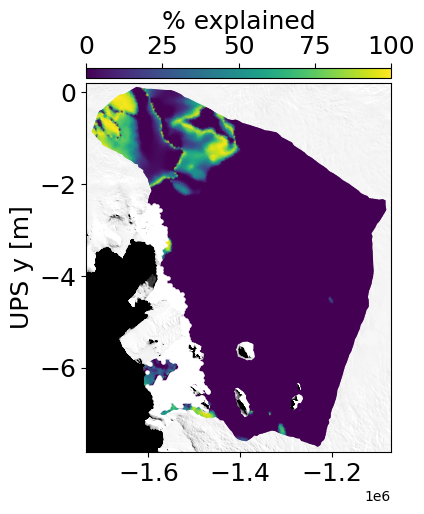

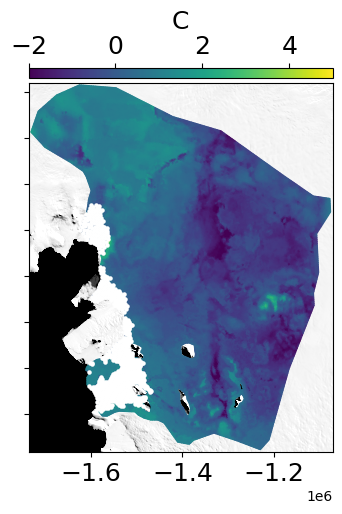

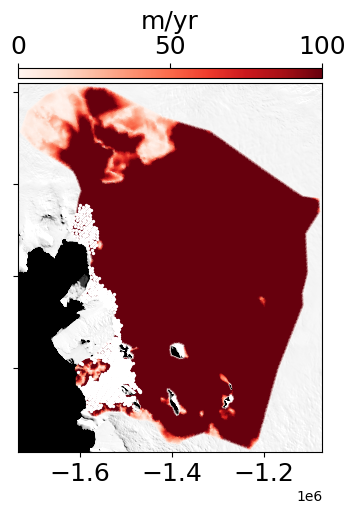

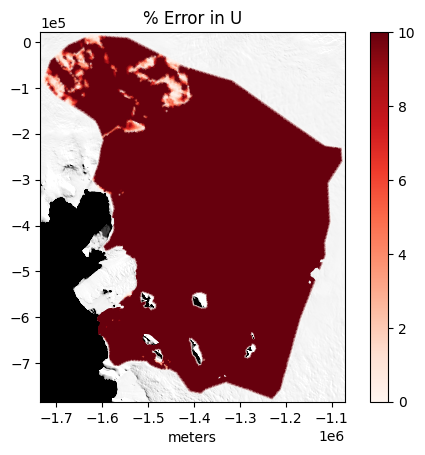

In [42]:
#4: 7, 11, 12, 13, 14
#1: 2, 13, 6, 16, 0
plot_single_feature_amundsen(
    select_dataset=6,
    feature_index=0,
    eval_results=eval_results,
    inv_loss_amundsen=inv_loss_amundsen
)